In [10]:
import os
import numpy as np
import pywt
import time
import cv2
from pathlib import Path
from scipy.fft import fft2, fftshift
from scipy.fft import dctn
from skimage.feature import local_binary_pattern

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt

In [14]:
#Notebook variables definition
DATA_ROOT   = Path("dataset")

SPLITS = {
    "train": {"real": DATA_ROOT / "train" / "real", "fake": DATA_ROOT / "train" / "fake"},
    "valid": {"real": DATA_ROOT / "valid" / "real", "fake": DATA_ROOT / "valid" / "fake"},
    "test":  {"real": DATA_ROOT / "test"  / "real", "fake": DATA_ROOT / "test"  / "fake"},
}

FEATURES_DIR = Path("features_stage1")
FEATURES_DIR.mkdir(exist_ok=True)

CHECKPOINT_DIR = Path("checkpoints_stage1")
CHECKPOINT_DIR.mkdir(exist_ok=True)


IMAGE_SIZE = (128, 128)

#For feature extraction
LBP_POINTS   = 8
LBP_RADIUS   = 2
LBP_BINS     = 59          # nri_uniform with P=8, 59 uniform patterns

FFT_BINS     = 64          # number of radial frequency bins

DCT_BLOCK    = 8           # top-left (DCT_BLOCK * DCT_BLOCK) coefficients kept

WAVELET      = "db1"
WAVELET_LEVEL = 2          # subbands: 3*level + 1, 7 subbands × 2 stats = 14 features

#For training
BATCH_SIZE   = 256
LR           = 1e-3
EPOCHS       = 30
DROPOUT      = 0.4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [15]:
#Feature extraction functions

def extract_lbp(gray):
    """LBP histogram — 59 bins (nri_uniform, P=8, R=2)."""
    lbp = local_binary_pattern(gray, P=LBP_POINTS, R=LBP_RADIUS, method='nri_uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_BINS + 1), density=True)
    return hist.astype(np.float32)


def extract_fft(gray):
    """Radial average of log-magnitude FFT spectrum — FFT_BINS values."""
    mag = np.abs(fftshift(fft2(gray.astype(np.float32))))
    log_mag = np.log1p(mag)

    h, w = log_mag.shape
    cy, cx = h // 2, w // 2
    radii = np.hypot(*np.indices((h, w)) - np.array([cy, cx])[:, None, None]).ravel()

    max_r = min(cy, cx)
    bin_idx = np.clip((radii / max_r * FFT_BINS).astype(int), 0, FFT_BINS - 1)

    flat = log_mag.ravel()
    counts = np.bincount(bin_idx, minlength=FFT_BINS)
    sums   = np.bincount(bin_idx, weights=flat, minlength=FFT_BINS)
    spectrum = np.where(counts > 0, sums / counts, 0).astype(np.float32)
    return spectrum


def extract_dct(gray):
    """Top-left DCT_BLOCK×DCT_BLOCK DCT coefficients, flattened."""
    coeffs = dctn(gray.astype(np.float32), norm='ortho')
    return coeffs[:DCT_BLOCK, :DCT_BLOCK].flatten().astype(np.float32)


def extract_wavelet(gray):
    """Mean + std of every subband from a WAVELET_LEVEL 2D DWT."""
    coeffs = pywt.wavedec2(gray.astype(np.float32), wavelet=WAVELET, level=WAVELET_LEVEL)
    feats = [coeffs[0].mean(), coeffs[0].std()]
    for detail_tuple in coeffs[1:]:
        for subband in detail_tuple:
            feats.extend([subband.mean(), subband.std()])
    return np.array(feats, dtype=np.float32)


def load_and_resize_gray(img_path):
    """Load image, resize, return (bgr, gray). Returns None on failure."""
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    img = cv2.resize(img, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

In [43]:
#DO NOT RERUN
#Extracting and saving features

def extract_features_from_folder(folder_path):
    """Extract all four features for every image in a folder."""
    lbp_list, fft_list, dct_list, wav_list, names = [], [], [], [], []

    img_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    for filename in img_files:
        _, gray = load_and_resize_gray(Path(folder_path) / filename)
        if gray is None:
            print(f"  [WARN] Could not read {filename}, skipping.")
            continue
        lbp_list.append(extract_lbp(gray))
        fft_list.append(extract_fft(gray))
        dct_list.append(extract_dct(gray))
        wav_list.append(extract_wavelet(gray))
        names.append(filename)

    return {
        'lbp':      np.array(lbp_list),
        'fft':      np.array(fft_list),
        'dct':      np.array(dct_list),
        'wavelet':  np.array(wav_list),
        'filenames': np.array(names)
    }


for split, classes in SPLITS.items():
    for cls, folder in classes.items():
        out_path = FEATURES_DIR / f"{split}_{cls}_features.npz"

        if out_path.exists():
            print(f"[SKIP] {out_path.name}")
            continue

        print(f"\n[EXTRACTING] {split}/{cls}  ({folder})")
        t0 = time.time()
        data = extract_features_from_folder(folder)
        elapsed = time.time() - t0

        np.savez_compressed(out_path, **data)
        n = len(data['filenames'])
        print(f"  {n} images | {elapsed:.1f}s | saved → {out_path.name}")

print("\n Feature dimensions")
sample = np.load(FEATURES_DIR / "train_real_features.npz")
total  = 0
for key in ['lbp', 'fft', 'dct', 'wavelet']:
    d = sample[key].shape[1]
    total += d
    print(f"  {key:<10} {d:>4} features")
print(f"  {'TOTAL':<10} {total:>4} features")

[SKIP] train_real_features.npz
[SKIP] train_fake_features.npz
[SKIP] valid_real_features.npz
[SKIP] valid_fake_features.npz
[SKIP] test_real_features.npz
[SKIP] test_fake_features.npz

 Feature dimensions
  lbp          59 features
  fft          64 features
  dct          64 features
  wavelet      14 features
  TOTAL       201 features


In [22]:
#Load features before standardizing
import joblib

FEATURE_KEYS = ['lbp', 'fft', 'dct', 'wavelet']
SCALER_PATH  = FEATURES_DIR / "scaler.joblib"


def load_split_features(split_name):
    """Load, concatenate, and label real+fake features for one split."""
    real_data = np.load(FEATURES_DIR / f"{split_name}_real_features.npz")
    fake_data = np.load(FEATURES_DIR / f"{split_name}_fake_features.npz")

    X_real = np.concatenate([real_data[k] for k in FEATURE_KEYS], axis=1)
    X_fake = np.concatenate([fake_data[k] for k in FEATURE_KEYS], axis=1)

    X = np.vstack([X_real, X_fake]).astype(np.float32)
    y = np.hstack([
        np.ones(len(X_real),  dtype=np.float32),   # real = 1
        np.zeros(len(X_fake), dtype=np.float32)    # fake = 0
    ])
    return X, y


X_train_raw, y_train = load_split_features('train')
X_valid_raw, y_valid = load_split_features('valid')
X_test_raw,  y_test  = load_split_features('test')

In [24]:
class FeatureDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


#Fitting/loading scaler
if SCALER_PATH.exists():
    print(f"[SKIP] Loading scaler from {SCALER_PATH.name}")
    scaler = joblib.load(SCALER_PATH)
else:
    print("Fitting StandardScaler on training features")
    scaler = StandardScaler()
    scaler.fit(X_train_raw)
    joblib.dump(scaler, SCALER_PATH)
    print(f"Scaler saved: {SCALER_PATH.name}")

#Fit on train
X_train = scaler.transform(X_train_raw).astype(np.float32)
X_valid = scaler.transform(X_valid_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)


train_dataset = FeatureDataset(X_train, y_train)
valid_dataset = FeatureDataset(X_valid, y_valid)
test_dataset  = FeatureDataset(X_test,  y_test)

#num_workers=0 avoids multiprocessing issues
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


input_dim = X_train.shape[1]
print(f"\n Dataset summary")
print(f"  Feature vector dim : {input_dim}")
for name, ds, y in [("Train", train_dataset, y_train),
                    ("Valid", valid_dataset, y_valid),
                    ("Test",  test_dataset,  y_test)]:
    print(f"  {name:<6}: {len(ds):>6} samples  "
          f"(real={int(y.sum())}, fake={int((y == 0).sum())})")

[SKIP] Loading scaler from scaler.joblib

 Dataset summary
  Feature vector dim : 201
  Train :  30000 samples  (real=15000, fake=15000)
  Valid :   5000 samples  (real=2500, fake=2500)
  Test  :   5000 samples  (real=2500, fake=2500)


In [25]:
#MLP build
class FCNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple = (512, 128), dropout: float = DROPOUT):
        super().__init__()

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))  #single logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1) 


model = FCNet(input_dim=input_dim).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

FCNet(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

Trainable parameters: 170,497


In [26]:
#Setup and training functions
CHECKPOINT_PATH = CHECKPOINT_DIR / "fc_best.pt"

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == y_batch).sum().item()
        total   += len(y_batch)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        running_loss += loss.item() * len(y_batch)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == y_batch).sum().item()
        total   += len(y_batch)
    return running_loss / total, correct / total

In [28]:
#Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

if CHECKPOINT_PATH.exists():
    print(f"[SKIP] Checkpoint found — loading {CHECKPOINT_PATH.name}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    history       = ckpt['history']
    best_val_loss = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training for {EPOCHS} epochs \n")
    for epoch in range(EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, valid_loader, criterion)
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':              history,
            }, CHECKPOINT_PATH)
            tag = ' <-'

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"train loss {train_loss:.4f}  acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f}  acc {val_acc:.4f} | "
              f"{elapsed:.1f}s{tag}")

    print(f"\nDone. Best val loss: {best_val_loss:.4f}")

#Restore best weights before evaluation
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print("\nBest weights loaded")

[SKIP] Checkpoint found — loading fc_best.pt
  Best val loss: 0.4108  (epoch 19)

Best weights loaded


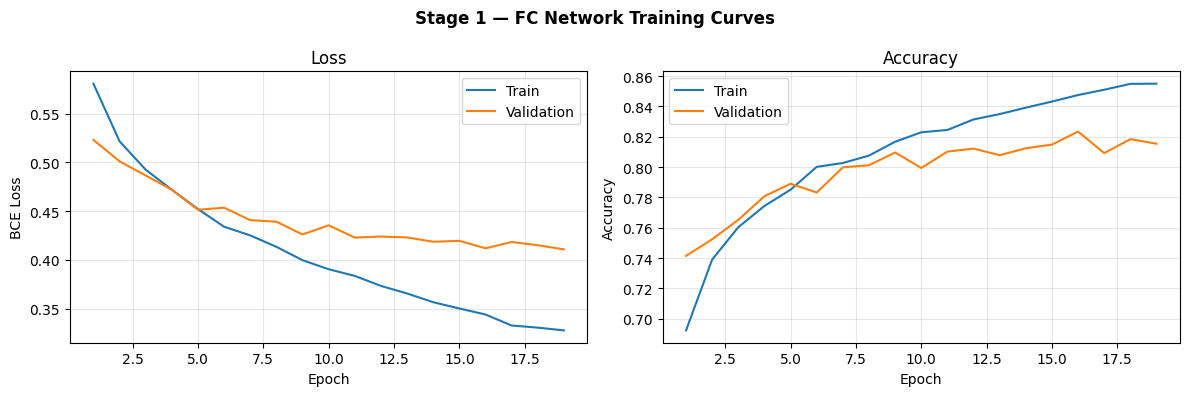

In [29]:
#Training curves plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_x, history['train_loss'], label='Train')
ax1.plot(epochs_x, history['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history['train_acc'], label='Train')
ax2.plot(epochs_x, history['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Stage 1 — FC Network Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
#Inference helper
@torch.no_grad()
def get_predictions(model, loader):
    """Run inference over a loader, returns (y_true, y_pred, y_prob) as numpy arrays."""
    model.eval()
    all_labels, all_probs = [], []
    for X_batch, y_batch in loader:
        probs = torch.sigmoid(model(X_batch.to(DEVICE))).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())
    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true, y_pred, y_prob


def compute_metrics(y_true, y_pred, y_prob, dataset_name):
    """Compute, print, and return the full metric suite."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n {dataset_name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                  Pred Fake  Pred Real")
    print(f"  Actual Fake :   {tn:6d}     {fp:6d}")
    print(f"  Actual Real :   {fn:6d}     {tp:6d}")
    print(f"\n  TN {tn} : correctly identified as Fake")
    print(f"  FP {fp} : Fake images wrongly called Real")
    print(f"  FN {fn} : Real images wrongly called Fake")
    print(f"  TP {tp} : correctly identified as Real")

    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auc=auc, cm=cm)

In [38]:
#Evaluating on validation set
y_true_val, y_pred_val, y_prob_val = get_predictions(model, valid_loader)
metrics_val = compute_metrics(y_true_val, y_pred_val, y_prob_val, "Validation")


 Validation
  Accuracy  : 0.8154
  Precision : 0.8214
  Recall    : 0.8060
  F1        : 0.8136
  ROC-AUC   : 0.8964

  Confusion Matrix:
                  Pred Fake  Pred Real
  Actual Fake :     2062        438
  Actual Real :      485       2015

  TN 2062 : correctly identified as Fake
  FP 438 : Fake images wrongly called Real
  FN 485 : Real images wrongly called Fake
  TP 2015 : correctly identified as Real


In [42]:
tn, fp, fn, tp = confusion_matrix(y_true_val, y_pred_val).ravel()
print(f"Sample check: of {tn+fp} actual Fake images, {tn} were correctly called Fake")
print(f"Sample check: of {tp+fn} actual Real images, {tp} were correctly called Real")

Sample check: of 2500 actual Fake images, 2062 were correctly called Fake
Sample check: of 2500 actual Real images, 2015 were correctly called Real


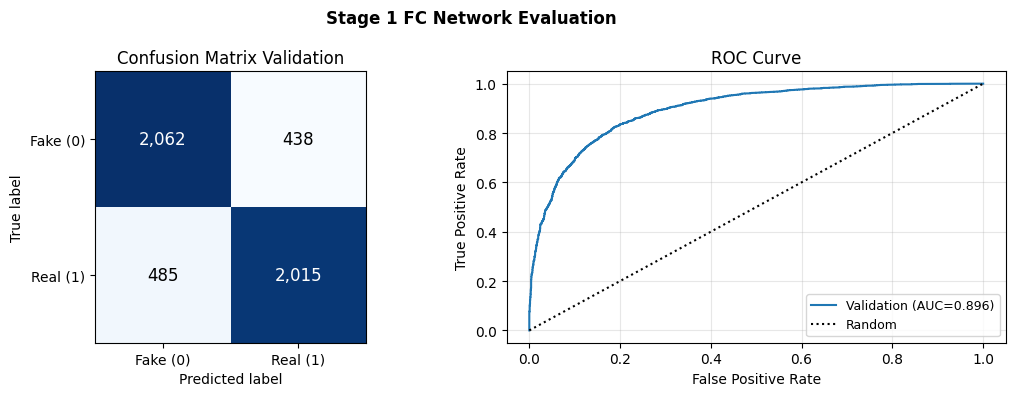

In [41]:
#Confusion Matrix & ROC Curve
def plot_cm(ax, cm, title):
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set(title=title, ylabel='True label', xlabel='Predicted label')
    labels = ['Fake (0)', 'Real (1)']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=12)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_val['cm'], 'Confusion Matrix Validation')

fpr, tpr, _ = roc_curve(y_true_val, y_prob_val)
ax2.plot(fpr, tpr, label=f"Validation (AUC={metrics_val['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('Stage 1 FC Network Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation.png', dpi=150, bbox_inches='tight')
plt.show()